In [1]:
import requests 
census_api_key = '503a45c2c4a9be075f1f523252e01e7a305885a7'
url = "https://api.census.gov/data/2023/acs/acs5/subject?get=group(S1901)&ucgid=860Z200US10001,860Z200US10002"\
    .format(census_api_key)

response = requests.request("GET", url)
     

In [2]:
response.status_code

200

In [4]:
response.json()

[['GEO_ID',
  'NAME',
  'S1901_C01_001E',
  'S1901_C01_001EA',
  'S1901_C01_001M',
  'S1901_C01_001MA',
  'S1901_C01_002E',
  'S1901_C01_002EA',
  'S1901_C01_002M',
  'S1901_C01_002MA',
  'S1901_C01_003E',
  'S1901_C01_003EA',
  'S1901_C01_003M',
  'S1901_C01_003MA',
  'S1901_C01_004E',
  'S1901_C01_004EA',
  'S1901_C01_004M',
  'S1901_C01_004MA',
  'S1901_C01_005E',
  'S1901_C01_005EA',
  'S1901_C01_005M',
  'S1901_C01_005MA',
  'S1901_C01_006E',
  'S1901_C01_006EA',
  'S1901_C01_006M',
  'S1901_C01_006MA',
  'S1901_C01_007E',
  'S1901_C01_007EA',
  'S1901_C01_007M',
  'S1901_C01_007MA',
  'S1901_C01_008E',
  'S1901_C01_008EA',
  'S1901_C01_008M',
  'S1901_C01_008MA',
  'S1901_C01_009E',
  'S1901_C01_009EA',
  'S1901_C01_009M',
  'S1901_C01_009MA',
  'S1901_C01_010E',
  'S1901_C01_010EA',
  'S1901_C01_010M',
  'S1901_C01_010MA',
  'S1901_C01_011E',
  'S1901_C01_011EA',
  'S1901_C01_011M',
  'S1901_C01_011MA',
  'S1901_C01_012E',
  'S1901_C01_012EA',
  'S1901_C01_012M',
  'S1901_C01_01

In [9]:
len(response.json()[0])

259

In [257]:
import pandas as pd

######## features to consider... ########
#income by race 
#raw population counts (by race)
#proportion of homeowners (w/ a mortgage specifically)

population_map = {
    'TOTAL POPULATION ESTIMATE': 'B01001_001E', 
    'POPULATION W': 'B01001A_001E',
    'POPULATION B': 'B01001B_001E',
    'POPULATION AAPI': 'B01001D_001E',
    'POPULATION H': 'B01001I_001E',
    'MEDIAN_AGE': 'B01002_001E'

}

income_map = {
    'PER CAPITA INCOME': 'B19301_001E',
    'PER CAPITA INCOME W': 'B19301A_001E',
    'PER CAPITA INCOME B': 'B19301B_001E',
    'PER CAPITA INCOME AAPI': 'B19301D_001E',
    'PER CAPITA INCOME H': 'B19301I_001E',
    'PER CAPITA INCOME A15-24': 'B19049_002E',
    'PER CAPITA INCOME A25-44': 'B19049_003E',
    'PER CAPITA INCOME A45-64': 'B19049_004E',
    'PER CAPITA INCOME A65+': 'B19049_005E'
}

housing_mobility_map = {
    'TOTAL HH POP': 'B07013_001E',
    'SAME H 1 YR':'B07013_002E',
    'SAME STATE':'B07013_004E',
    'DIFFERENT STATE':'B07013_013E',
    'ABROAD': 'B07013_015E'
}

#ratio of mortaaged/non-mortgaged households? averaged LTV? use as indicators to describe aggregated credit status per zip  
#15 yr 30 yr mortgages not tracked 
#just assume 30 yr? 
#or estimate distribution based on global assumption 
#note, this data isn't available beyond 2023
credit_risk_vars = {
    'MORTGAGE': 'B25101_002E',
    'TOTAL': 'B25101_001E',
    'MEDIAN_HH_VALUE':'B25097_003E', 
    'MEDIAN_MONTHLY_MORTGAGE':'B25088_003E'
}

##### 

test_zip = 11101 
test_ucgid = '860Z200US' + str(test_zip)
var_codes = ','.join(
   list(population_map.values()) \
  + list(income_map.values()) \
  + list(housing_mobility_map.values()) 
)

url = f'https://api.census.gov/data/2021/acs/acs5?get=NAME,{var_codes}&ucgid={test_ucgid}' 

response = requests.request("GET", url)

#why tf is no data being returned for any year not 2021-2023?? look into this
url


'https://api.census.gov/data/2021/acs/acs5?get=NAME,B01001_001E,B01001A_001E,B01001B_001E,B01001D_001E,B01001I_001E,B01002_001E,B19301_001E,B19301A_001E,B19301B_001E,B19301D_001E,B19301I_001E,B19049_002E,B19049_003E,B19049_004E,B19049_005E,B07013_001E,B07013_002E,B07013_004E,B07013_013E,B07013_015E&ucgid=860Z200US11101'

In [258]:
response.status_code

200

In [247]:
var_codes

'B01001_001E,B01001A_001E,B01001B_001E,B01001D_001E,B01001I_001E,B01002_001E,B19301_001E,B19301A_001E,B19301B_001E,B19301D_001E,B19301I_001E,B19049_002E,B19049_003E,B19049_004E,B19049_005E,B07013_001E,B07013_002E,B07013_004E,B07013_013E,B07013_015E'

In [248]:
pd.DataFrame(
    data=response.json()[1],
    index=['ZCTA'] \
        + list(population_map.keys()) \
        + list(income_map.keys()) \
        + list(housing_mobility_map.keys()) 
        + ['ucgid'],
    columns=['attr']
)

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [184]:
1501*30*12

540360

In [282]:
###### retrieve all ZCTAs based on what's in the Redfin dataset as a collection, and pass them as ucgis id's into the request 

import duckdb 
from tqdm import tqdm 

con=duckdb.connect(
    '../datasets/combined_data2.db'
)

zips_FL = con.sql(
    '''
    select distinct zip from redfin_dataset where STATE_CODE = 'FL' 
    ;
    '''
).df()['zip']

headers = requests.utils.default_headers()
headers.update(
    {
        'User-Agent': 'PostmanRuntime/7.43.4',
    }
)

import numpy as np

years = np.arange(2021,2024)
blocks_it = np.arange(0,len(zips_FL),len(zips_FL)//10)
all_ = []

for year in tqdm(years):
    print(year)
    for idx, _ in list(enumerate(blocks_it))[:-1]:
        print(idx)
        i_start = blocks_it[idx]
        i_end = blocks_it[idx+1]

        zips_block = zips_FL.loc[i_start:i_end]
        usgis_id_block = ','.join('860Z200US' + zips_block)
        url_block = f'https://api.census.gov/data/{year}/acs/acs5?get=NAME,{var_codes}&ucgid={usgis_id_block}' 
        print(url_block)

        response = requests.get(url_block, headers=headers)
        print(response.status_code)
        assert response.status_code == 200
    
        data = response.json() 

        values = data[1:]
        columns = ['ZCTA'] \
            + list(population_map.keys()) \
            + list(income_map.keys()) \
            + list(housing_mobility_map.keys()) \
            + ['ucgid']
        tbl = pd.DataFrame(data=values,columns=columns)
        tbl['year'] = int(year)
        tbl['zip']=tbl['ZCTA'].str.strip('ZCTA5 ')
        tbl = tbl.drop(columns=['ucgid','ZCTA'])
        tbl = tbl.astype(np.float64)
        all_.append(tbl)

sample_FL23 = pd.concat(all_)

sample_FL23.head(25)




  0%|          | 0/3 [00:00<?, ?it/s]

2021
0
https://api.census.gov/data/2021/acs/acs5?get=NAME,B01001_001E,B01001A_001E,B01001B_001E,B01001D_001E,B01001I_001E,B01002_001E,B19301_001E,B19301A_001E,B19301B_001E,B19301D_001E,B19301I_001E,B19049_002E,B19049_003E,B19049_004E,B19049_005E,B07013_001E,B07013_002E,B07013_004E,B07013_013E,B07013_015E&ucgid=860Z200US33018,860Z200US32765,860Z200US32824,860Z200US34743,860Z200US33140,860Z200US32216,860Z200US33803,860Z200US32701,860Z200US33634,860Z200US34113,860Z200US32210,860Z200US32190,860Z200US33762,860Z200US34446,860Z200US32681,860Z200US33981,860Z200US32934,860Z200US34607,860Z200US32234,860Z200US33983,860Z200US33029,860Z200US34661,860Z200US33474,860Z200US34275,860Z200US34239,860Z200US34285,860Z200US33760,860Z200US32130,860Z200US33434,860Z200US33097,860Z200US33576,860Z200US33946,860Z200US32033,860Z200US33716,860Z200US32911,860Z200US34237,860Z200US34221,860Z200US32444,860Z200US32409,860Z200US34749,860Z200US32524,860Z200US33130,860Z200US33162,860Z200US34240,860Z200US33064,860Z200US3343

 33%|███▎      | 1/3 [00:04<00:09,  4.80s/it]

200
2022
0
https://api.census.gov/data/2022/acs/acs5?get=NAME,B01001_001E,B01001A_001E,B01001B_001E,B01001D_001E,B01001I_001E,B01002_001E,B19301_001E,B19301A_001E,B19301B_001E,B19301D_001E,B19301I_001E,B19049_002E,B19049_003E,B19049_004E,B19049_005E,B07013_001E,B07013_002E,B07013_004E,B07013_013E,B07013_015E&ucgid=860Z200US33018,860Z200US32765,860Z200US32824,860Z200US34743,860Z200US33140,860Z200US32216,860Z200US33803,860Z200US32701,860Z200US33634,860Z200US34113,860Z200US32210,860Z200US32190,860Z200US33762,860Z200US34446,860Z200US32681,860Z200US33981,860Z200US32934,860Z200US34607,860Z200US32234,860Z200US33983,860Z200US33029,860Z200US34661,860Z200US33474,860Z200US34275,860Z200US34239,860Z200US34285,860Z200US33760,860Z200US32130,860Z200US33434,860Z200US33097,860Z200US33576,860Z200US33946,860Z200US32033,860Z200US33716,860Z200US32911,860Z200US34237,860Z200US34221,860Z200US32444,860Z200US32409,860Z200US34749,860Z200US32524,860Z200US33130,860Z200US33162,860Z200US34240,860Z200US33064,860Z200US

 67%|██████▋   | 2/3 [00:09<00:04,  4.79s/it]

200
2023
0
https://api.census.gov/data/2023/acs/acs5?get=NAME,B01001_001E,B01001A_001E,B01001B_001E,B01001D_001E,B01001I_001E,B01002_001E,B19301_001E,B19301A_001E,B19301B_001E,B19301D_001E,B19301I_001E,B19049_002E,B19049_003E,B19049_004E,B19049_005E,B07013_001E,B07013_002E,B07013_004E,B07013_013E,B07013_015E&ucgid=860Z200US33018,860Z200US32765,860Z200US32824,860Z200US34743,860Z200US33140,860Z200US32216,860Z200US33803,860Z200US32701,860Z200US33634,860Z200US34113,860Z200US32210,860Z200US32190,860Z200US33762,860Z200US34446,860Z200US32681,860Z200US33981,860Z200US32934,860Z200US34607,860Z200US32234,860Z200US33983,860Z200US33029,860Z200US34661,860Z200US33474,860Z200US34275,860Z200US34239,860Z200US34285,860Z200US33760,860Z200US32130,860Z200US33434,860Z200US33097,860Z200US33576,860Z200US33946,860Z200US32033,860Z200US33716,860Z200US32911,860Z200US34237,860Z200US34221,860Z200US32444,860Z200US32409,860Z200US34749,860Z200US32524,860Z200US33130,860Z200US33162,860Z200US34240,860Z200US33064,860Z200US

100%|██████████| 3/3 [00:14<00:00,  4.79s/it]

200


,TOTAL POPULATION ESTIMATE,POPULATION W,POPULATION B,POPULATION AAPI,POPULATION H,MEDIAN_AGE,PER CAPITA INCOME,PER CAPITA INCOME W,PER CAPITA INCOME B,PER CAPITA INCOME AAPI,...,PER CAPITA INCOME A25-44,PER CAPITA INCOME A45-64,PER CAPITA INCOME A65+,TOTAL HH POP,SAME H 1 YR,SAME STATE,DIFFERENT STATE,ABROAD,year,zip
0,4666.0,4392.0,138.0,61.0,238.0,53.7,40417.0,40631.0,34023.0,NaN,...,180417.0,64837.0,75225.0,4525.0,3763.0,3969.0,149.0,0.0,2021.0,32033.0
1,16184.0,10365.0,4914.0,111.0,536.0,36.4,23703.0,27207.0,18378.0,23741.0,...,39746.0,52443.0,35841.0,15427.0,9854.0,13329.0,92.0,35.0,2021.0,320.0
2,32753.0,29209.0,960.0,640.0,2380.0,50.1,34269.0,35908.0,16045.0,23280.0,...,67342.0,74885.0,47464.0,32080.0,23726.0,26637.0,1615.0,982.0,2021.0,32086.0
3,4756.0,3572.0,42.0,15.0,1652.0,45.3,28071.0,32813.0,NaN,NaN,...,51293.0,63487.0,48825.0,4660.0,3787.0,4167.0,42.0,0.0,2021.0,32130.0
4,30060.0,27248.0,1336.0,180.0,1821.0,55.5,38914.0,40678.0,18724.0,17186.0,...,72240.0,59489.0,54255.0,29792.0,23413.0,25638.0,1727.0,1027.0,2021.0,32168.0
5,1524.0,734.0,141.0,2.0,710.0,41.3,24662.0,32267.0,15226.0,NaN,...,-666666666.0,125918.0,32159.0,1508.0,1278.0,1409.0,0.0,0.0,2021.0,32190.0
6,66824.0,32009.0,26723.0,2418.0,6076.0,35.7,29961.0,39575.0,21304.0,26392.0,...,52027.0,57973.0,40239.0,65563.0,35458.0,55891.0,1243.0,971.0,2021.0,32210.0
7,39762.0,23794.0,9083.0,2473.0,7406.0,37.5,35547.0,36187.0,22928.0,21850.0,...,60876.0,68602.0,35989.0,38195.0,18813.0,32278.0,917.0,783.0,2021.0,32216.0
8,12020.0,7700.0,2750.0,347.0,923.0,44.3,29791.0,34923.0,16967.0,32259.0,...,67923.0,71422.0,44113.0,11841.0,10161.0,9805.0,214.0,34.0,2021.0,32220.0
9,7780.0,6497.0,830.0,33.0,293.0,39.3,30058.0,32181.0,17390.0,NaN,...,115355.0,74583.0,45703.0,7684.0,6590.0,6159.0,454.0,259.0,2021.0,32234.0


In [194]:
sample_FL23.loc['32827']

TOTAL POPULATION ESTIMATE             19601
POPULATION W                          10926
POPULATION B                           2282
POPULATION AAPI                        1285
POPULATION H                           6836
MEDIAN_AGE                             38.3
PER CAPITA INCOME                     49206
PER CAPITA INCOME W                   57973
PER CAPITA INCOME B                   34877
PER CAPITA INCOME AAPI                55835
PER CAPITA INCOME H                   40586
PER CAPITA INCOME A15-24         -666666666
PER CAPITA INCOME A25-44             111510
PER CAPITA INCOME A45-64             141806
PER CAPITA INCOME A65+                75595
TOTAL HH POP                          19294
SAME H 1 YR                           13843
SAME STATE                            16849
DIFFERENT STATE                         963
ABROAD                                  864
MORTGAGE                               3386
TOTAL                                  4296
MEDIAN_HH_VALUE                 

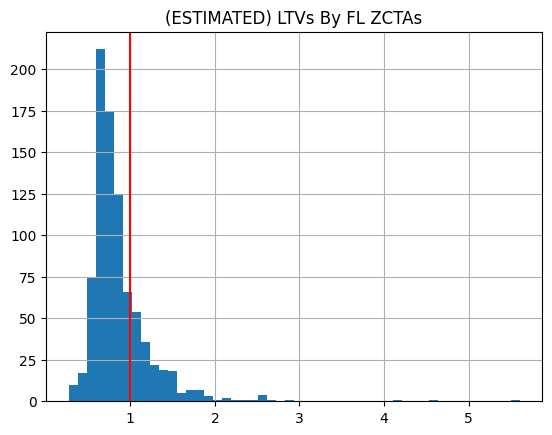

In [216]:
sample_FL23['MEDIAN_HH_VALUE'].value_counts()
sample_FL23 = sample_FL23.loc[
    (sample_FL23['MEDIAN_HH_VALUE']>0)
   &(sample_FL23['MEDIAN_MONTHLY_MORTGAGE']>0)
]

#calculate ltv ratio, assume a 30-yr mortgage
sample_FL23['ESTIMATED_LTV'] = (sample_FL23['MEDIAN_MONTHLY_MORTGAGE'].astype(int)*30*12)/sample_FL23['MEDIAN_HH_VALUE'].astype(int)

sample_FL23['ESTIMATED_LTV'].hist(bins=50)

import matplotlib.pyplot as plt 

plt.axvline(1, color='red')
plt.title('(ESTIMATED) LTVs By FL ZCTAs')
plt.show()

In [223]:
#grab claims data 
import io 

hdma_query = 'https://ffiec.cfpb.gov/v2/data-browser-api/view/csv?states=FL&years=2019'
res = requests.get(hdma_query)

In [290]:
subqueryclaims_re = f'''
        with realestate_data as (
        select * from redfin_dataset where STATE_CODE = 'FL'
        )
        select 
            year, 
            zip::INT as zip, 
            STATE_CODE, 
            avg(MEDIAN_SALE_PRICE::DOUBLE) as home_price, 
            sum(claimCounts) as claimCounts, 
            sum(numEvents) as numEvents, 
            sum(totalClaimZip) as totalClaimZip, 
            sum(totalLossesZip) as totalLossesZip
        from realestate_data 
        left join nfip_claims_zip using (zip,month,year)
        where 
            MEDIAN_SALE_PRICE <> 'NA'
        group by 1,2,3
        order by zip,year
        ;


        '''

claims_realestate = con.sql(subqueryclaims_re)

data_pr = claims_realestate.df()


In [291]:
sample_FL23.dtypes

TOTAL POPULATION ESTIMATE    float64
POPULATION W                 float64
POPULATION B                 float64
POPULATION AAPI              float64
POPULATION H                 float64
MEDIAN_AGE                   float64
PER CAPITA INCOME            float64
PER CAPITA INCOME W          float64
PER CAPITA INCOME B          float64
PER CAPITA INCOME AAPI       float64
PER CAPITA INCOME H          float64
PER CAPITA INCOME A15-24     float64
PER CAPITA INCOME A25-44     float64
PER CAPITA INCOME A45-64     float64
PER CAPITA INCOME A65+       float64
TOTAL HH POP                 float64
SAME H 1 YR                  float64
SAME STATE                   float64
DIFFERENT STATE              float64
ABROAD                       float64
year                         float64
zip                          float64
dtype: object

In [294]:
ttl=data_pr.merge(
    sample_FL23, 
    how='inner', 
    on=[
        'year','zip'
    ]
)

len(ttl['zip'].unique())

801

In [300]:
ttl

,year,zip,STATE_CODE,home_price,claimCounts,numEvents,totalClaimZip,totalLossesZip,TOTAL POPULATION ESTIMATE,POPULATION W,...,PER CAPITA INCOME H,PER CAPITA INCOME A15-24,PER CAPITA INCOME A25-44,PER CAPITA INCOME A45-64,PER CAPITA INCOME A65+,TOTAL HH POP,SAME H 1 YR,SAME STATE,DIFFERENT STATE,ABROAD
0,2021,32003,FL,4.010212e+05,NaN,NaN,NaN,NaN,29505.0,24623.0,...,25100.0,-666666666.0,101910.0,127405.0,87069.0,29399.0,25548.0,25297.0,1357.0,608.0
1,2022,32003,FL,4.702875e+05,14.0,14.0,704056.15,508793.0,29810.0,24209.0,...,30272.0,-666666666.0,102875.0,149705.0,96277.0,29530.0,25213.0,25046.0,1365.0,788.0
2,2023,32003,FL,4.691583e+05,1.0,0.0,0.00,0.0,29351.0,23949.0,...,27746.0,-666666666.0,109878.0,150250.0,96728.0,28917.0,25712.0,25535.0,878.0,381.0
3,2021,32009,FL,3.206833e+05,NaN,NaN,NaN,NaN,3372.0,3184.0,...,96568.0,-666666666.0,76736.0,71855.0,37656.0,3311.0,2919.0,3118.0,0.0,0.0
4,2022,32009,FL,3.923417e+05,NaN,NaN,NaN,NaN,3582.0,3375.0,...,148530.0,74770.0,101250.0,76378.0,42143.0,3489.0,3076.0,3274.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2394,2022,34996,FL,1.038917e+06,8.0,8.0,14612.12,29084.0,10755.0,9796.0,...,32685.0,-666666666.0,101429.0,116852.0,75122.0,10645.0,9254.0,9139.0,406.0,155.0
2395,2023,34996,FL,9.385000e+05,1.0,0.0,25707.32,26957.0,10875.0,9889.0,...,32358.0,-666666666.0,85802.0,108601.0,76579.0,10809.0,9351.0,9301.0,383.0,96.0
2396,2021,34997,FL,4.335667e+05,4.0,3.0,56758.73,58984.0,44630.0,37747.0,...,19568.0,48060.0,72871.0,74209.0,55742.0,44058.0,35175.0,39356.0,956.0,267.0
2397,2022,34997,FL,5.039583e+05,5.0,5.0,751865.97,63184.0,45562.0,37889.0,...,22551.0,54400.0,91747.0,81335.0,65012.0,44762.0,36204.0,40745.0,1027.0,321.0
